--- Phase 1: Data Cleaning & Feature Engineering ---
Final dataset shape: (546, 36)

--- Phase 2: Precondition Checks ---
  feature        VIF
0   const  83.727883

--- Phase 3: Model Estimation ---
Model Converged: True
AIC: 15334.86 | BIC: -2724.36

--- Phase 4: Diagnostics ---
Dispersion Parameter (phi): 1.2145
>> Note: For Gamma, phi is approx inverse shape parameter. phi=1.21
Diagnostic plots saved as 'glm_diagnostics.png'
[Check] Max Cook's Distance: 1.7355
Note: Influential points detected. Check top leverage points.

--- Phase 5: Inference ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:         monto_otorgado   No. Observations:                  546
Model:                            GLM   Df Residuals:                      510
Model Family:                   Gamma   Df Model:                           35
Link Function:                    log   Scale:                          1.2145
Method:                          IRLS   Log-Lik

/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


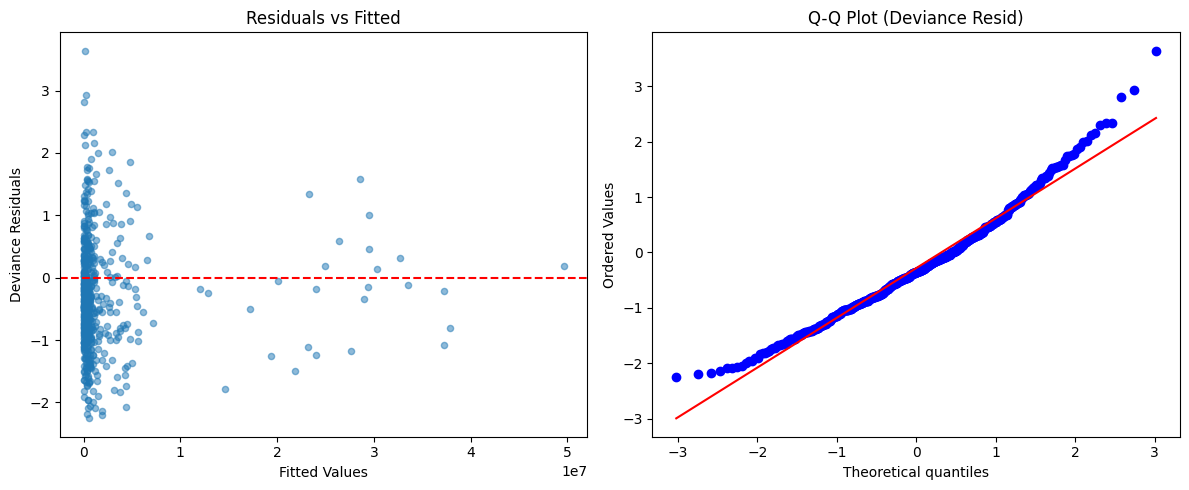

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from scipy.stats import skew

class DataCleaner:
    def __init__(self, df, target_col):
        self.df = df.copy()
        self.target_col = target_col
        
    def reduce_cardinality(self, col, top_n=7, other_label='OTHER'):
        if col not in self.df.columns: return
        top_categories = self.df[col].value_counts().nlargest(top_n).index
        self.df[col] = self.df[col].apply(lambda x: x if x in top_categories else other_label)

    def process(self):
        print("--- Phase 1: Data Cleaning & Feature Engineering ---")
        
        # 1. Standardize Column Names
        new_columns = {
            'FECHA': 'fecha', 'SUBSISTEMA': 'subsistema', 'ENTIDAD': 'entidad',
            'TIPO DE CREDITO': 'tipo_de_credito', 'TIPO DE OPERACION': 'tipo_de_operacion',
            'ESTADO DE LA OPERACION': 'estado_de_la_operacion', 'PROVINCIA': 'provincia',
            'CANTON': 'canton', 'SECTOR': 'sector', 'SUBSECTOR': 'subsector',
            'ACTIVIDAD': 'actividad', 'NÚMERO DE OPERACIONES': 'numero_de_operaciones',
            'MONTO OTORGADO': 'monto_otorgado'
        }
        self.df = self.df.rename(columns=new_columns)
        # Update target_col name to the new standard
        self.target_col = 'monto_otorgado'

        # 2. Date Correction (Handling mixed formats)
        original_fecha = self.df['fecha'].copy()
        self.df['fecha'] = pd.to_datetime(self.df['fecha'], format='%d/%m/%Y', errors='coerce')
        na_mask = self.df['fecha'].isna()
        self.df.loc[na_mask, 'fecha'] = pd.to_datetime(original_fecha[na_mask], format='%m/%d/%Y', errors='coerce')
        
        # Extract Quarter for seasonal effects before dropping 'fecha'
        self.df['quarter'] = self.df['fecha'].dt.to_period('Q').astype(str)
        self.df.drop(columns=['fecha'], inplace=True)

        # 3. Sector Cleaning & Standardization
        agri_std = 'AGRICULTURA, GANADERÍA, SILVICULTURA Y PESCA'
        com_std = 'COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS AUTOMOTORES Y MOTOCICLETAS'
        self.df['sector'] = self.df['sector'].str.replace(r'AGRICULTURA.*SILVICULTURA Y PESCA', agri_std, regex=True)
        self.df['sector'] = self.df['sector'].str.replace(r'COMERCIO AL POR MAYOR Y AL POR MENOR.*MOTOCICLETAS', com_std, regex=True)

        # 4. Drop Constants & High-Cardinality predictors
        nunique = self.df.nunique()
        const_cols = nunique[nunique <= 1].index.tolist()
        high_card_cols = ['canton', 'subsector', 'actividad']
        self.df.drop(columns=const_cols + high_card_cols, inplace=True, errors='ignore')

        # 5. Dimensionality Reduction for remaining categoricals
        for col in ['provincia', 'sector']:
            self.reduce_cardinality(col, top_n=6)

        # 6. Final Type Conversion and Encoding
        self.df[self.target_col] = pd.to_numeric(self.df[self.target_col], errors='coerce')
        self.df.dropna(subset=[self.target_col], inplace=True)
        
        cat_cols = self.df.select_dtypes(include=['object', 'category']).columns.tolist()
        self.df = pd.get_dummies(self.df, columns=cat_cols, drop_first=True, dtype=int)
        
        print(f"Final dataset shape: {self.df.shape}")
        return self.df
class RigorousGLM:
    """
    Scientific GLM Pipeline: Assumptions -> Estimation -> Diagnostics -> Inference
    """
    def __init__(self, data, target, family=None):
        self.df = data.copy()
        self.target = target
        # All columns except target are predictors
        self.predictors = [c for c in self.df.columns if c != target]
        
        self.family = family if family else sm.families.Gaussian()
        self.model = None
        self.result = None
        
    def check_preconditions(self):
        print("\n--- Phase 2: Precondition Checks ---")
        X = add_constant(self.df[self.predictors])
        
        # VIF Check
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        # Handle potential singular matrix in VIF by try-except or simple check
        try:
            vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
            print(vif_data[vif_data["VIF"] > 5])
            if vif_data["VIF"].max() > 10:
                print("WARNING: Severe Multicollinearity detected. Standard errors may be unreliable.")
        except Exception as e:
            print(f"VIF Calculation skipped due to singularity: {e}")

    def fit_model(self):
        print("\n--- Phase 3: Model Estimation ---")
        X = add_constant(self.df[self.predictors])
        y = self.df[self.target]
        
        try:
            self.model = sm.GLM(y, X, family=self.family)
            self.result = self.model.fit()
            print(f"Model Converged: {self.result.converged}")
            print(f"AIC: {self.result.aic:.2f} | BIC: {self.result.bic:.2f}")
        except Exception as e:
            print(f"Model Fitting Failed: {e}")

    def run_diagnostics(self):
        if not self.result: return
        print("\n--- Phase 4: Diagnostics ---")
        
        # 1. Overdispersion
        phi = self.result.pearson_chi2 / self.result.df_resid
        print(f"Dispersion Parameter (phi): {phi:.4f}")
        if isinstance(self.family, sm.families.Poisson) and phi > 1.5:
             print(">> CRITICAL: Overdispersion detected. Switch family.")
        elif isinstance(self.family, sm.families.Gamma):
             print(f">> Note: For Gamma, phi is approx inverse shape parameter. phi={phi:.2f}")

        # 2. Residual Plots
        resid = self.result.resid_deviance
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        
        # Deviance Residuals vs Fitted
        ax[0].scatter(self.result.mu, resid, alpha=0.5, s=20)
        ax[0].axhline(0, color='r', linestyle='--')
        ax[0].set_xlabel('Fitted Values')
        ax[0].set_ylabel('Deviance Residuals')
        ax[0].set_title('Residuals vs Fitted')
        
        # Q-Q Plot
        stats.probplot(resid, dist="norm", plot=ax[1])
        ax[1].set_title('Q-Q Plot (Deviance Resid)')
        
        plt.tight_layout()
        plt.savefig('glm_diagnostics.png')
        print("Diagnostic plots saved as 'glm_diagnostics.png'")

        # C. Influence (Cook's Distance)
        # Identifying points that disproportionately affect parameters
        influence = self.result.get_influence()
        cooks_d = influence.cooks_distance[0]
        max_cooks = np.max(cooks_d)
        print(f"[Check] Max Cook's Distance: {max_cooks:.4f}")
        if max_cooks > 4 / len(self.df):
            print("Note: Influential points detected. Check top leverage points.")
            
    def report_inference(self):
        if not self.result: return
        print("\n--- Phase 5: Inference ---")
        print(self.result.summary())
        
# --- EXECUTION ---
filename = 'cfn_volumencreditocontingente_2025_enero-septiembre.csv'
raw_df = pd.read_csv(filename, sep=';', encoding='latin-1')

# Run Clean
cleaner = DataCleaner(raw_df, target_col='MONTO OTORGADO')
processed_df = cleaner.process()

# Run GLM Pipeline (using Gamma with Log link for monetary values)
pipeline = RigorousGLM(
    data=processed_df, 
    target='monto_otorgado', 
    family=sm.families.Gamma(link=sm.families.links.log())
)

pipeline.check_preconditions()
pipeline.fit_model()
pipeline.run_diagnostics()
pipeline.report_inference()

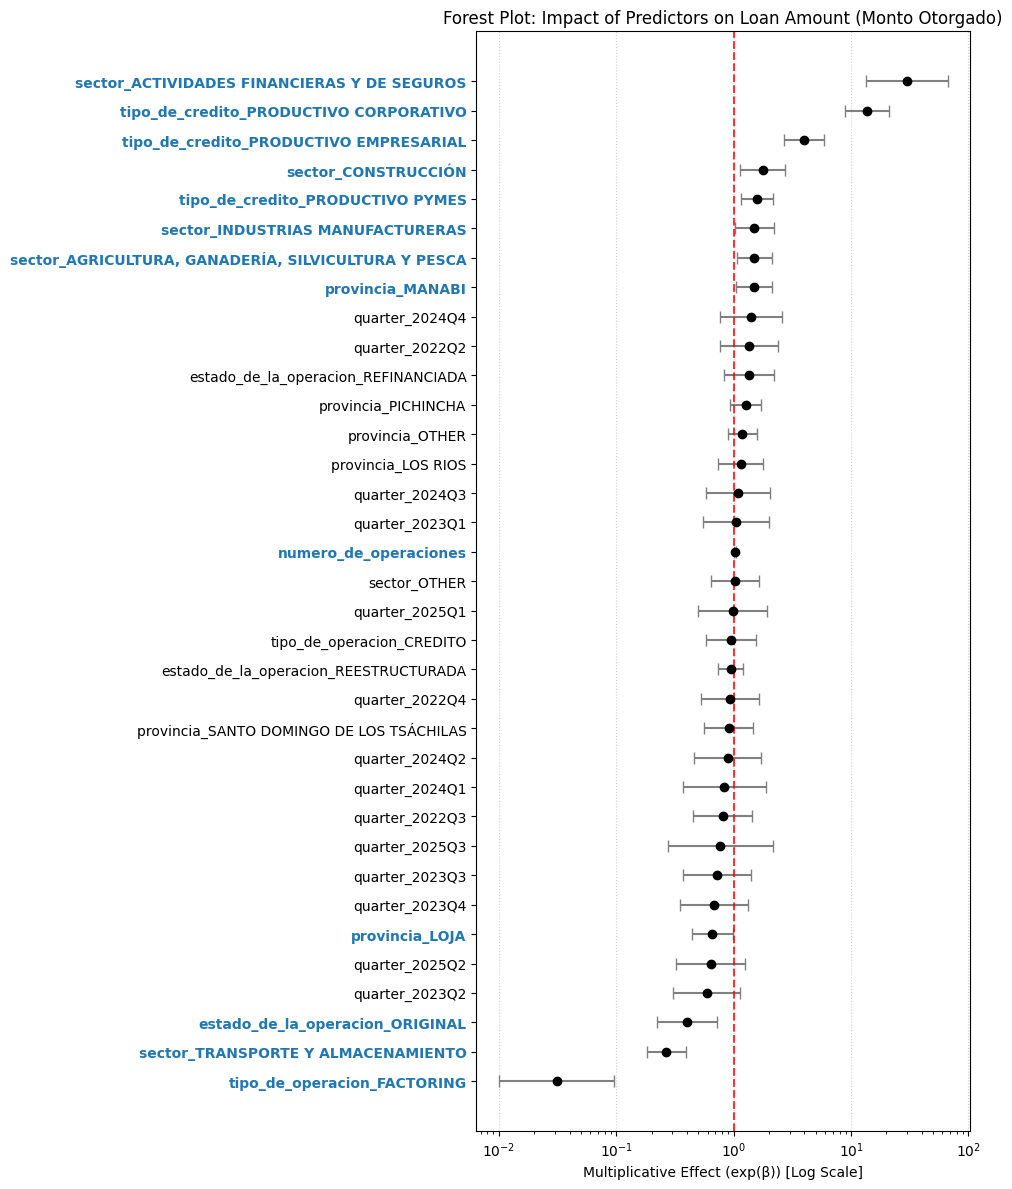

In [2]:
# Coefficient Plot (Forest Plot)
def plot_glm_forest(result):
    """
    Generates a forest plot of exponentiated coefficients (exp(beta)).
    :param result: The fitted statsmodels GLM result object.
    """
    # 1. Extract coefficients and 95% Confidence Intervals
    summary_df = pd.DataFrame({
        'coef': result.params,
        'lower': result.conf_int()[0],
        'upper': result.conf_int()[1],
        'pvalues': result.pvalues
    })

    # 2. Exponentiate to get the Multiplicative Effect
    summary_df[['exp_coef', 'exp_lower', 'exp_upper']] = np.exp(
        summary_df[['coef', 'lower', 'upper']]
    )

    # 3. Drop the Intercept (constant) and sort by effect size
    plot_df = summary_df.drop('const').sort_values('exp_coef')

    # 4. Initialize Plot
    plt.figure(figsize=(10, 12))
    
    # Use errorbar to plot the point estimate and CI
    plt.errorbar(
        plot_df['exp_coef'], 
        range(len(plot_df)), 
        xerr=[plot_df['exp_coef'] - plot_df['exp_lower'], 
              plot_df['exp_upper'] - plot_df['exp_coef']],
        fmt='o', color='black', ecolor='gray', capsize=4, label='exp(β) with 95% CI'
    )

    # 5. Styling
    plt.yticks(range(len(plot_df)), plot_df.index)
    plt.axvline(x=1, color='red', linestyle='--', alpha=0.8, label='Null Effect (1.0)')
    
    # Use Log Scale for the X-axis (essential for multiplicative effects)
    plt.xscale('log') 
    
    # Clean up labels for scientific presentation
    plt.xlabel('Multiplicative Effect (exp(β)) [Log Scale]')
    plt.title('Forest Plot: Impact of Predictors on Loan Amount (Monto Otorgado)')
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)

    # 6. Formatting significant labels
    significant = plot_df['pvalues'] < 0.05
    ax = plt.gca()
    for i, is_sig in enumerate(significant):
        if is_sig:
            ax.get_yticklabels()[i].set_fontweight('bold')
            ax.get_yticklabels()[i].set_color('#1f77b4') # Highlight significant in blue

    plt.tight_layout()
    plt.savefig('glm_forest_plot.png')
    plt.show()

# Execute
plot_glm_forest(pipeline.result)

Skewness: 7.306347818742258
Min: 2553.27
Mean: 2182551.139120879
Median: 240018.33500000002


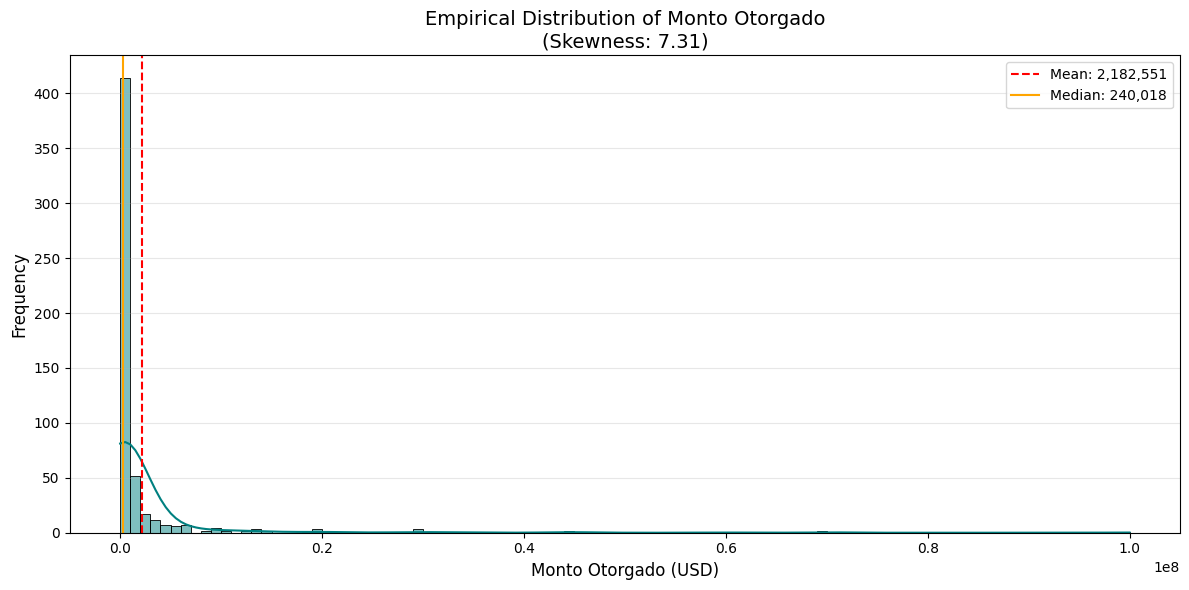

In [3]:
# Convert target to numeric
target = 'MONTO OTORGADO'
raw_df[target] = pd.to_numeric(raw_df[target], errors='coerce')
y = raw_df[target].dropna()

# Calculate statistics for the response
y_skew = skew(y)
y_min = y.min()
y_mean = y.mean()
y_median = y.median()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot 1: Standard Histogram to show the extreme right skew
sns.histplot(y, bins=100, kde=True, color='teal')
plt.title(f'Empirical Distribution of Monto Otorgado\n(Skewness: {y_skew:.2f})', fontsize=14)
plt.xlabel('Monto Otorgado (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(y_mean, color='red', linestyle='--', label=f'Mean: {y_mean:,.0f}')
plt.axvline(y_median, color='orange', linestyle='-', label=f'Median: {y_median:,.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('target_skewness_linear.png')

print(f"Skewness: {y_skew}")
print(f"Min: {y_min}")
print(f"Mean: {y_mean}")
print(f"Median: {y_median}")

Phi: 1.2144616250746216, Alpha: 0.823410126226554, Avg Mu: 2116781.531857487


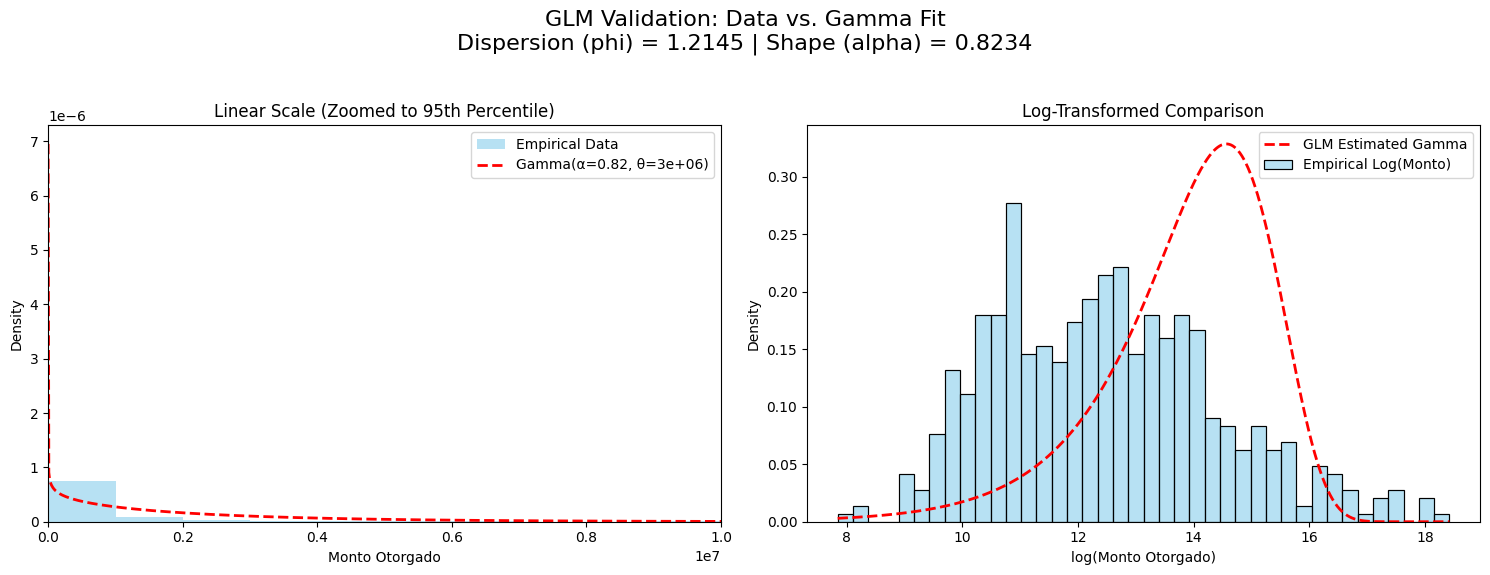

In [4]:
# Extract parameters for log scale plot
# 3. Extract Parameters
phi = pipeline.result.scale
alpha = 1 / phi
mu_bar = pipeline.result.predict().mean()  # Mean of the predicted values
theta_bar = mu_bar / alpha     # Scale parameter theta = mu / alpha

# 4. Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Linear Scale (Zoomed)
# We zoom to 95th percentile to see the distribution shape
limit = np.percentile(y, 95)
x_lin = np.linspace(0.1, limit, 1000)
pdf_lin = stats.gamma.pdf(x_lin, a=alpha, scale=theta_bar)

ax[0].hist(y, bins=100, density=True, color='skyblue', alpha=0.6, label='Empirical Data')
ax[0].plot(x_lin, pdf_lin, 'r--', lw=2, label=f'Gamma(α={alpha:.2f}, θ={theta_bar:.0e})')
ax[0].set_xlim(0, limit)
ax[0].set_title('Linear Scale (Zoomed to 95th Percentile)')
ax[0].set_xlabel('Monto Otorgado')
ax[0].set_ylabel('Density')
ax[0].legend()

# Plot B: Log-Log plot or Log-transformed visualization
# Log-transforming the x-axis for better visibility of the fit across all scales
log_y = np.log(y)
sns.histplot(log_y, bins=40, kde=False, stat="density", color="skyblue", alpha=0.6, ax=ax[1], label="Empirical Log(Monto)")
z_range = np.linspace(log_y.min(), log_y.max(), 1000)
y_range = np.exp(z_range)
# PDF adjustment for change of variables: f_Z(z) = f_Y(exp(z)) * exp(z)
pdf_z = stats.gamma.pdf(y_range, a=alpha, scale=theta_bar) * y_range
ax[1].plot(z_range, pdf_z, 'r--', lw=2, label='GLM Estimated Gamma')
ax[1].set_title('Log-Transformed Comparison')
ax[1].set_xlabel('log(Monto Otorgado)')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.suptitle(f"GLM Validation: Data vs. Gamma Fit\nDispersion (phi) = {phi:.4f} | Shape (alpha) = {alpha:.4f}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('glm_gamma_verification.png')

print(f"Phi: {phi}, Alpha: {alpha}, Avg Mu: {mu_bar}")

In [5]:
# 2. Kolmogorov-Smirnov Test using Probability Integral Transform (PIT)
# In a GLM, each y_i has a different mean mu_i. 
# We transform each y_i into a value in [0, 1] using its specific Gamma CDF.
X = add_constant(processed_df.drop(columns=['monto_otorgado', 'fecha'], errors='ignore'))
y = processed_df['monto_otorgado']
mu = pipeline.result.predict(X)
phi = pipeline.result.scale
alpha = 1 / phi
theta = mu / alpha

# Calculate PIT values: P_i = P(Y <= y_i)
pit_values = stats.gamma.cdf(y, a=alpha, scale=theta)

# Perform K-S test against a Uniform(0, 1) distribution
ks_stat, p_value = stats.kstest(pit_values, 'uniform')

print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretation logic
if p_value > 0.05:
    print("Result: Fail to reject H0. The data distribution is consistent with the fitted Gamma model.")
else:
    print("Result: Reject H0. There are significant deviations from the theoretical Gamma distribution.")

K-S Statistic: 0.1134
P-value: 1.4305e-06
Result: Reject H0. There are significant deviations from the theoretical Gamma distribution.


#### Note:
The current Gamma GLM is not accurately capturing the probability of high-value loans. To improve this, we can try to do the same analysis excluding Insurance and Financial Activities sector.

In [8]:
processed_df.columns

Index(['numero_de_operaciones', 'monto_otorgado',
       'tipo_de_credito_PRODUCTIVO CORPORATIVO',
       'tipo_de_credito_PRODUCTIVO EMPRESARIAL',
       'tipo_de_credito_PRODUCTIVO PYMES', 'tipo_de_operacion_CREDITO',
       'tipo_de_operacion_FACTORING', 'estado_de_la_operacion_ORIGINAL',
       'estado_de_la_operacion_REESTRUCTURADA',
       'estado_de_la_operacion_REFINANCIADA', 'provincia_LOJA',
       'provincia_LOS RIOS', 'provincia_MANABI', 'provincia_OTHER',
       'provincia_PICHINCHA', 'provincia_SANTO DOMINGO DE LOS TSÁCHILAS',
       'sector_ACTIVIDADES FINANCIERAS Y DE SEGUROS',
       'sector_AGRICULTURA, GANADERÍA, SILVICULTURA Y PESCA',
       'sector_CONSTRUCCIÓN', 'sector_INDUSTRIAS MANUFACTURERAS',
       'sector_OTHER', 'sector_TRANSPORTE Y ALMACENAMIENTO', 'quarter_2022Q2',
       'quarter_2022Q3', 'quarter_2022Q4', 'quarter_2023Q1', 'quarter_2023Q2',
       'quarter_2023Q3', 'quarter_2023Q4', 'quarter_2024Q1', 'quarter_2024Q2',
       'quarter_2024Q3', 'quarter_

Original shape: (546, 36)
Refined shape: (546, 34)

--- Phase 2: Precondition Checks ---
  feature        VIF
0   const  76.875468

--- Phase 3: Model Estimation ---
Model Converged: False
AIC: 15568.23 | BIC: -2524.39

--- Phase 4: Diagnostics ---
Dispersion Parameter (phi): 1.7341
>> Note: For Gamma, phi is approx inverse shape parameter. phi=1.73
Diagnostic plots saved as 'glm_diagnostics.png'
[Check] Max Cook's Distance: 3.3044
Note: Influential points detected. Check top leverage points.

--- Phase 5: Inference ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:         monto_otorgado   No. Observations:                  546
Model:                            GLM   Df Residuals:                      512
Model Family:                   Gamma   Df Model:                           33
Link Function:                    log   Scale:                          1.7341
Method:                          IRLS   Log-Likelihood:                -7750.1


/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/equina/Documents/Generalized_Linear_Model_CFN/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


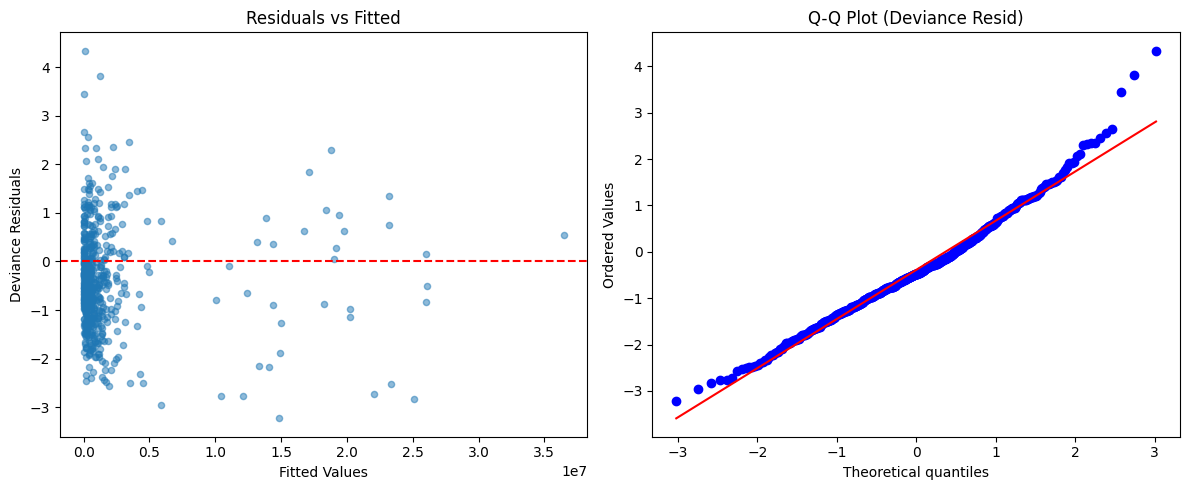

In [16]:
# 1. Filter the data to exclude the specific sector
# We create a copy to avoid SettingWithCopy warnings
df_refined = processed_df.drop(columns=['sector_ACTIVIDADES FINANCIERAS Y DE SEGUROS','tipo_de_credito_PRODUCTIVO CORPORATIVO']).copy()

print(f"Original shape: {processed_df.shape}")
print(f"Refined shape: {df_refined.shape}")


# Run GLM Pipeline (using Gamma with Log link for monetary values)
pipeline2 = RigorousGLM(
    data=df_refined, 
    target='monto_otorgado', 
    family=sm.families.Gamma(link=sm.families.links.log())
)

pipeline2.check_preconditions()
pipeline2.fit_model()
pipeline2.run_diagnostics()
pipeline2.report_inference()

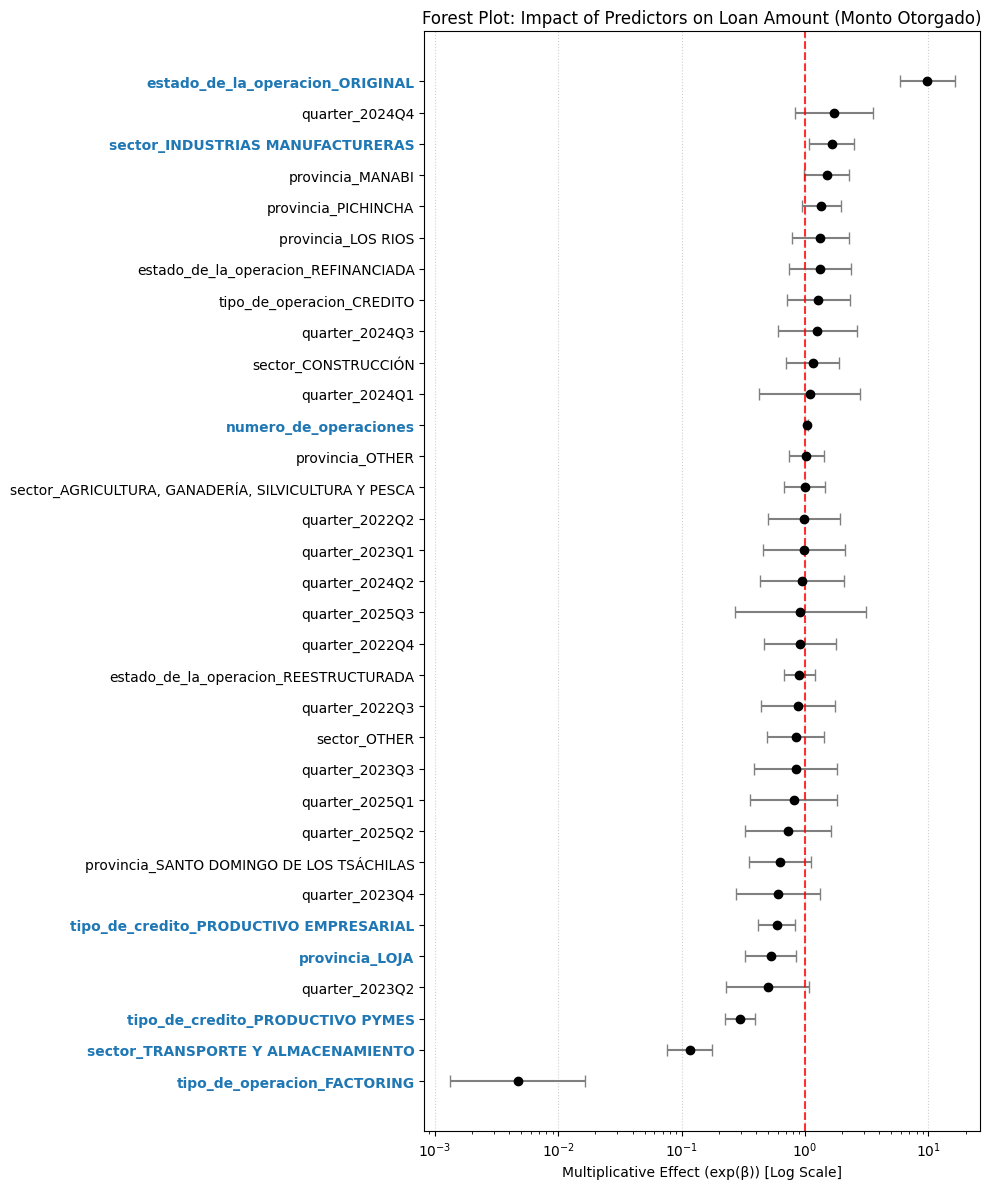

In [17]:
# Coefficient Plot (Forest Plot)
def plot_glm_forest(result):
    """
    Generates a forest plot of exponentiated coefficients (exp(beta)).
    :param result: The fitted statsmodels GLM result object.
    """
    # 1. Extract coefficients and 95% Confidence Intervals
    summary_df = pd.DataFrame({
        'coef': result.params,
        'lower': result.conf_int()[0],
        'upper': result.conf_int()[1],
        'pvalues': result.pvalues
    })

    # 2. Exponentiate to get the Multiplicative Effect
    summary_df[['exp_coef', 'exp_lower', 'exp_upper']] = np.exp(
        summary_df[['coef', 'lower', 'upper']]
    )

    # 3. Drop the Intercept (constant) and sort by effect size
    plot_df = summary_df.drop('const').sort_values('exp_coef')

    # 4. Initialize Plot
    plt.figure(figsize=(10, 12))
    
    # Use errorbar to plot the point estimate and CI
    plt.errorbar(
        plot_df['exp_coef'], 
        range(len(plot_df)), 
        xerr=[plot_df['exp_coef'] - plot_df['exp_lower'], 
              plot_df['exp_upper'] - plot_df['exp_coef']],
        fmt='o', color='black', ecolor='gray', capsize=4, label='exp(β) with 95% CI'
    )

    # 5. Styling
    plt.yticks(range(len(plot_df)), plot_df.index)
    plt.axvline(x=1, color='red', linestyle='--', alpha=0.8, label='Null Effect (1.0)')
    
    # Use Log Scale for the X-axis (essential for multiplicative effects)
    plt.xscale('log') 
    
    # Clean up labels for scientific presentation
    plt.xlabel('Multiplicative Effect (exp(β)) [Log Scale]')
    plt.title('Forest Plot: Impact of Predictors on Loan Amount (Monto Otorgado)')
    plt.grid(True, axis='x', linestyle=':', alpha=0.6)

    # 6. Formatting significant labels
    significant = plot_df['pvalues'] < 0.05
    ax = plt.gca()
    for i, is_sig in enumerate(significant):
        if is_sig:
            ax.get_yticklabels()[i].set_fontweight('bold')
            ax.get_yticklabels()[i].set_color('#1f77b4') # Highlight significant in blue

    plt.tight_layout()
    plt.savefig('glm_forest_plot.png')
    plt.show()

# Execute
plot_glm_forest(pipeline2.result)

Skewness: 7.306347818742258
Min: 2553.27
Mean: 2182551.139120879
Median: 240018.33500000002


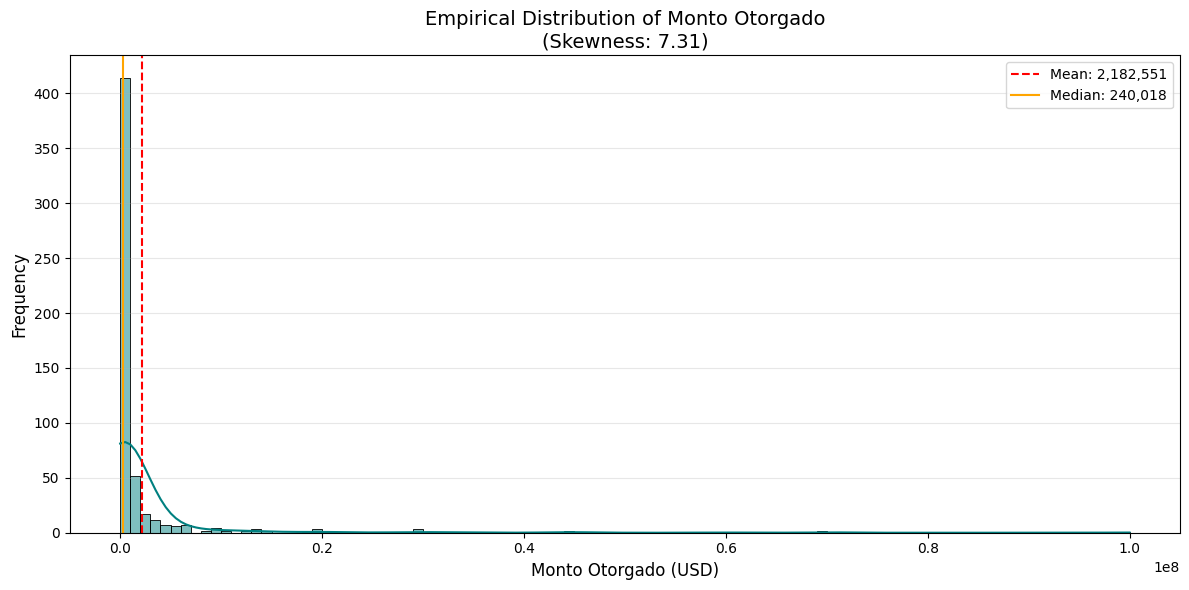

In [18]:
# Convert target to numeric
target = 'MONTO OTORGADO'
raw_df[target] = pd.to_numeric(raw_df[target], errors='coerce')
y = raw_df[target].dropna()

# Calculate statistics for the response
y_skew = skew(y)
y_min = y.min()
y_mean = y.mean()
y_median = y.median()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot 1: Standard Histogram to show the extreme right skew
sns.histplot(y, bins=100, kde=True, color='teal')
plt.title(f'Empirical Distribution of Monto Otorgado\n(Skewness: {y_skew:.2f})', fontsize=14)
plt.xlabel('Monto Otorgado (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(y_mean, color='red', linestyle='--', label=f'Mean: {y_mean:,.0f}')
plt.axvline(y_median, color='orange', linestyle='-', label=f'Median: {y_median:,.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('target_skewness_linear.png')

print(f"Skewness: {y_skew}")
print(f"Min: {y_min}")
print(f"Mean: {y_mean}")
print(f"Median: {y_median}")

Phi: 1.7341314971653787, Alpha: 0.5766575381593644, Avg Mu: 1940731.8567616306


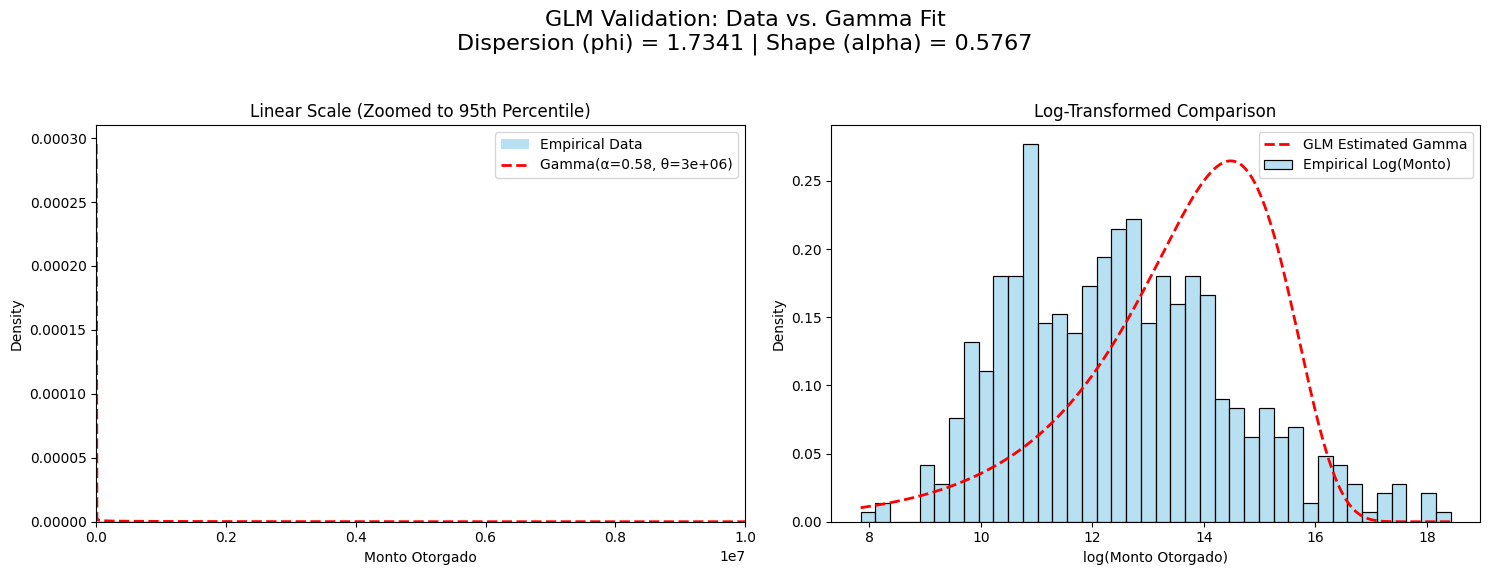

In [19]:
# Extract parameters for log scale plot
# 3. Extract Parameters
phi = pipeline2.result.scale
alpha = 1 / phi
mu_bar = pipeline2.result.predict().mean()  # Mean of the predicted values
theta_bar = mu_bar / alpha     # Scale parameter theta = mu / alpha

# 4. Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Linear Scale (Zoomed)
# We zoom to 95th percentile to see the distribution shape
limit = np.percentile(y, 95)
x_lin = np.linspace(0.1, limit, 1000)
pdf_lin = stats.gamma.pdf(x_lin, a=alpha, scale=theta_bar)

ax[0].hist(y, bins=100, density=True, color='skyblue', alpha=0.6, label='Empirical Data')
ax[0].plot(x_lin, pdf_lin, 'r--', lw=2, label=f'Gamma(α={alpha:.2f}, θ={theta_bar:.0e})')
ax[0].set_xlim(0, limit)
ax[0].set_title('Linear Scale (Zoomed to 95th Percentile)')
ax[0].set_xlabel('Monto Otorgado')
ax[0].set_ylabel('Density')
ax[0].legend()

# Plot B: Log-Log plot or Log-transformed visualization
# Log-transforming the x-axis for better visibility of the fit across all scales
log_y = np.log(y)
sns.histplot(log_y, bins=40, kde=False, stat="density", color="skyblue", alpha=0.6, ax=ax[1], label="Empirical Log(Monto)")
z_range = np.linspace(log_y.min(), log_y.max(), 1000)
y_range = np.exp(z_range)
# PDF adjustment for change of variables: f_Z(z) = f_Y(exp(z)) * exp(z)
pdf_z = stats.gamma.pdf(y_range, a=alpha, scale=theta_bar) * y_range
ax[1].plot(z_range, pdf_z, 'r--', lw=2, label='GLM Estimated Gamma')
ax[1].set_title('Log-Transformed Comparison')
ax[1].set_xlabel('log(Monto Otorgado)')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.suptitle(f"GLM Validation: Data vs. Gamma Fit\nDispersion (phi) = {phi:.4f} | Shape (alpha) = {alpha:.4f}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('glm_gamma_verification.png')

print(f"Phi: {phi}, Alpha: {alpha}, Avg Mu: {mu_bar}")

In [20]:
# 2. Kolmogorov-Smirnov Test using Probability Integral Transform (PIT)
# In a GLM, each y_i has a different mean mu_i. 
# We transform each y_i into a value in [0, 1] using its specific Gamma CDF.
X = add_constant(processed_df.drop(columns=['monto_otorgado', 'fecha'], errors='ignore'))
y = processed_df['monto_otorgado']
mu = pipeline.result.predict(X)
phi = pipeline.result.scale
alpha = 1 / phi
theta = mu / alpha

# Calculate PIT values: P_i = P(Y <= y_i)
pit_values = stats.gamma.cdf(y, a=alpha, scale=theta)

# Perform K-S test against a Uniform(0, 1) distribution
ks_stat, p_value = stats.kstest(pit_values, 'uniform')

print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretation logic
if p_value > 0.05:
    print("Result: Fail to reject H0. The data distribution is consistent with the fitted Gamma model.")
else:
    print("Result: Reject H0. There are significant deviations from the theoretical Gamma distribution.")

K-S Statistic: 0.1134
P-value: 1.4305e-06
Result: Reject H0. There are significant deviations from the theoretical Gamma distribution.
